# 04 — Phase 2b: Causal Ablation (H1, H2, H3)

Tests the proposal's causal hypotheses on Gemma 3 4B IT, using the SAE features identified in Phase 1 and the SVD baseline established in Phase 2a:

- **Causal feature labeling** (professor's method): for each candidate language feature, ablate it and measure (i) MGSM accuracy delta, (ii) target-language perplexity delta. Tag as LANGUAGE / REASONING / SHARED / JUNK. Done at layer 17 on the top-5 A∩B candidates per language (~25 features).
- **H1**: top-k LANGUAGE-tagged feature ablation reproduces Zhao gains. k ∈ {1, 5, 10, 20} on a 50-prompt dev split, then best-k on full 250×5. Controls: random-feature ablation, Deng-style top-monolinguality (no causal filter).
- **H2**: SAE-targeted vs SVD trade-off — accuracy × language fidelity scatter on full 250×5.
- **H3**: layer-wise contribution at {9, 17, 22, 29} on dev split (top-10 A∩B per layer, no causal filter so the layer comparison is apples-to-apples).

**Compute budget:** ~10–12 hours on A100. Every block checkpoints so a disconnect doesn't lose progress.

## 0. Setup

In [1]:
import os
import sys
from pathlib import Path

DRIVE_RESULTS = None

In [2]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_URL = 'https://github.com/kvrancic/nlp-project.git'

if IN_COLAB:
    REPO_DIR = '/content/nlp-project'
    if not Path(REPO_DIR).exists():
        get_ipython().system('git clone {REPO_URL} {REPO_DIR}')
    else:
        get_ipython().system('cd {REPO_DIR} && git pull --ff-only')
    os.chdir(REPO_DIR)
    get_ipython().system("pip install -q 'numpy>=2.0' langdetect -e .")
else:
    REPO_DIR = os.getcwd()  # PI/local: assume cwd is the repo root

# Evict cached src.* so re-imports pick up the latest code
for _mod_name in [m for m in list(sys.modules) if m == 'src' or m.startswith('src.')]:
    del sys.modules[_mod_name]

if IN_COLAB:
    from google.colab import userdata
    os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
    Path('.env').write_text(f'HF_TOKEN={os.environ["HF_TOKEN"]}\n')
else:
    from dotenv import load_dotenv
    load_dotenv()
    assert os.environ.get('HF_TOKEN'), 'HF_TOKEN missing in .env at repo root'

if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        DRIVE_RESULTS = Path('/content/drive/MyDrive/nlp-project-results')
        DRIVE_RESULTS.mkdir(exist_ok=True, parents=True)
    except Exception:
        DRIVE_RESULTS = None


In [3]:
import torch, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
from itertools import product

from src.config import (
    TARGET_LANGUAGES, SAE_SUBSET_LAYERS, SAE_WIDTH_16K, RESULTS_DIR, D_MODEL,
)
from src.data import load_mgsm, parse_answer_number, compute_accuracy
from src.model import load_model_and_tokenizer, load_saes_at_layers
from src.intervention import run_generate_with_hooks, get_sae_decoder_directions
from src.evaluation import compute_perplexity

torch.manual_seed(0); np.random.seed(0)
MAX_NEW_TOKENS = 384
N_DEV = 50
N_TEST = 250
PRIMARY_LAYER = 17  # Phase 2 H3 prediction: layers 17, 22 carry most interference
K_VALUES = [1, 5, 10, 20]

mkdir -p failed for path /home/ubuntu/.config/matplotlib: [Errno 13] Permission denied: '/home/ubuntu/.config/matplotlib'


Matplotlib created a temporary cache directory at /tmp/matplotlib-v9fxsg0w because there was an issue with the default path (/home/ubuntu/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 1. Load model, SAEs, Phase 1 features, Phase 2a baseline

In [4]:
model, tokenizer = load_model_and_tokenizer()
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

saes = load_saes_at_layers(
    layers=SAE_SUBSET_LAYERS,
    width=SAE_WIDTH_16K, l0_target='medium',
)

# Phase 1
phase1 = torch.load(RESULTS_DIR / 'phase1_features.pt', weights_only=False)
intersection = phase1['intersection_features']  # {layer: {lang: [feat_indices]}}
top_A        = phase1['top_features_A']
reasoning_features = phase1['reasoning_features']
print('Phase 1 loaded.')
for layer in SAE_SUBSET_LAYERS:
    sizes = {l: len(intersection[layer][l]) for l in TARGET_LANGUAGES}
    print(f'  layer {layer}: A∩B sizes = {sizes}')

# Phase 2a (baseline + Zhao)
phase2a = torch.load(RESULTS_DIR / 'phase2_zhao_baseline.pt', weights_only=False)
baseline_results = phase2a['baseline_results']
zhao_test        = phase2a['zhao_test']
print(f'\nPhase 2a loaded. Baseline avg = {phase2a["baseline_avg"]:.3f}, '
      f'Zhao avg = {phase2a["zhao_avg"]:.3f}')

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

  Loaded SAE for layer 9 (width=16384, l0=medium)


  Loaded SAE for layer 17 (width=16384, l0=medium)


  Loaded SAE for layer 22 (width=16384, l0=medium)


  Loaded SAE for layer 29 (width=16384, l0=medium)
Phase 1 loaded.
  layer 9: A∩B sizes = {'en': 9, 'zh': 4, 'es': 3, 'bn': 12, 'sw': 2}
  layer 17: A∩B sizes = {'en': 19, 'zh': 6, 'es': 9, 'bn': 16, 'sw': 11}
  layer 22: A∩B sizes = {'en': 6, 'zh': 16, 'es': 12, 'bn': 22, 'sw': 13}
  layer 29: A∩B sizes = {'en': 10, 'zh': 19, 'es': 10, 'bn': 15, 'sw': 11}

Phase 2a loaded. Baseline avg = 0.531, Zhao avg = 0.550


In [5]:
# MGSM prompts (chat template) and gold
mgsm = load_mgsm(TARGET_LANGUAGES)
def make_prompt(q):
    return tokenizer.apply_chat_template(
        [{'role': 'user', 'content': q}], tokenize=False, add_generation_prompt=True,
    )
prompts = {l: [make_prompt(ex['question']) for ex in mgsm[l]] for l in TARGET_LANGUAGES}
golds   = {l: [ex['answer_number']        for ex in mgsm[l]] for l in TARGET_LANGUAGES}
dev_prompts = {l: prompts[l][:N_DEV] for l in TARGET_LANGUAGES}
dev_golds   = {l: golds[l][:N_DEV]   for l in TARGET_LANGUAGES}

## 2. Helpers: ablate-and-evaluate

In [6]:
def ablation_config(layer: int, feature_indices: list[int]) -> dict:
    """Build {layer: directions} for run_generate_with_hooks."""
    if not feature_indices:
        return {}
    dirs = get_sae_decoder_directions(saes[layer], feature_indices).to(model.device)
    return {layer: dirs}

def evaluate_with_ablation(prompts_list, golds_list, layer, feature_indices,
                            positions='last', desc='ablate'):
    """Run generate with ablation hooks, parse answers, compute accuracy."""
    cfg = ablation_config(layer, feature_indices)
    if not cfg:
        # No-op: no features → just baseline-style generation.
        outputs = []
        for q in tqdm(prompts_list, desc=desc):
            inputs = tokenizer(q, return_tensors='pt').to(model.device)
            input_len = inputs['input_ids'].shape[1]
            with torch.no_grad():
                gen = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)
            outputs.append(tokenizer.decode(gen[0][input_len:], skip_special_tokens=True))
    else:
        outputs = run_generate_with_hooks(
            model, tokenizer, prompts_list, cfg,
            positions=positions, max_new_tokens=MAX_NEW_TOKENS,
        )
    preds = [parse_answer_number(o) for o in outputs]
    correct = [p is not None and abs(p - g) < 1e-6 for p, g in zip(preds, golds_list)]
    return {
        'accuracy': sum(correct) / max(len(correct), 1),
        'predictions': preds, 'outputs': outputs, 'correct': correct,
    }

def avg_acc(per_lang_results):
    return float(np.mean([r['accuracy'] for r in per_lang_results.values()]))

## 3. Causal feature labeling at PRIMARY_LAYER

For each top-5 A∩B candidate per language at layer 17:
- (i) MGSM accuracy delta on a 25-prompt dev slice (smaller than full dev to keep this section ≤90 min)
- (ii) Target-language perplexity delta on a 50-text held-out slice (MGSM problems 200–249 — disjoint from accuracy dev)

Then tag:
- LANGUAGE: ↑perplexity in that lang, ≈arithmetic (acc delta within ±2pp)
- REASONING: ↓arithmetic when ablated, ≈perplexity
- SHARED: hits both
- JUNK: hits neither

In [7]:
N_LABEL_DEV = 25
TOP_PER_LANG = 5

label_dev_prompts = {l: prompts[l][:N_LABEL_DEV] for l in TARGET_LANGUAGES}
label_dev_golds   = {l: golds[l][:N_LABEL_DEV]   for l in TARGET_LANGUAGES}

# Held-out text per language: questions 200-249 (raw, not chat-templated).
ppl_texts = {l: [mgsm[l][i]['question'] for i in range(200, 250)]
             for l in TARGET_LANGUAGES}

# Baseline accuracy on label-dev (ablation-free)
label_baseline_acc = {}
for lang in TARGET_LANGUAGES:
    r = evaluate_with_ablation(
        label_dev_prompts[lang], label_dev_golds[lang], PRIMARY_LAYER, [],
        desc=f'{lang} no-ablation baseline',
    )
    label_baseline_acc[lang] = r['accuracy']
    print(f'  {lang}: baseline acc on {N_LABEL_DEV} prompts = {r["accuracy"]:.3f}')

en no-ablation baseline:   0%|          | 0/25 [00:00<?, ?it/s]

  en: baseline acc on 25 prompts = 0.440


zh no-ablation baseline:   0%|          | 0/25 [00:00<?, ?it/s]

  zh: baseline acc on 25 prompts = 0.600


es no-ablation baseline:   0%|          | 0/25 [00:00<?, ?it/s]

  es: baseline acc on 25 prompts = 0.440


bn no-ablation baseline:   0%|          | 0/25 [00:00<?, ?it/s]

  bn: baseline acc on 25 prompts = 0.680


sw no-ablation baseline:   0%|          | 0/25 [00:00<?, ?it/s]

  sw: baseline acc on 25 prompts = 0.400


In [8]:
# Baseline perplexity per language
baseline_ppl = {}
for lang in TARGET_LANGUAGES:
    ppls = compute_perplexity(model, tokenizer, ppl_texts[lang])
    baseline_ppl[lang] = float(np.mean(ppls))
    print(f'  {lang}: baseline ppl = {baseline_ppl[lang]:.2f}')

Computing perplexity:   0%|          | 0/50 [00:00<?, ?it/s]

Computing perplexity:   2%|▏         | 1/50 [00:00<00:06,  7.06it/s]

Computing perplexity:   6%|▌         | 3/50 [00:00<00:03, 13.10it/s]

Computing perplexity:  10%|█         | 5/50 [00:00<00:02, 15.53it/s]

Computing perplexity:  14%|█▍        | 7/50 [00:00<00:02, 16.38it/s]

...

Computing perplexity:  92%|█████████▏| 46/50 [00:02<00:00, 18.19it/s]

Computing perplexity:  96%|█████████▌| 48/50 [00:02<00:00, 14.75it/s]

Computing perplexity: 100%|██████████| 50/50 [00:03<00:00, 15.85it/s]

Computing perplexity: 100%|██████████| 50/50 [00:03<00:00, 16.47it/s]

  sw: baseline ppl = 58.19


In [9]:
import importlib
import src.intervention
importlib.reload(src.intervention)
from src.intervention import run_generate_with_hooks, get_sae_decoder_directions


In [10]:
# For each top-5 A∩B candidate per language at PRIMARY_LAYER, run ablation
# and measure both deltas. Records → causal_labels[(lang, feat)] = {...}.
from src.model import get_decoder_layers
DECODER_LAYERS = get_decoder_layers(model)

candidates = {}  # lang -> [feat indices]
for lang in TARGET_LANGUAGES:
    inter = intersection[PRIMARY_LAYER][lang]
    if len(inter) >= TOP_PER_LANG:
        cand = inter[:TOP_PER_LANG]
    else:
        # Backfill from Method A if intersection is thin.
        extra = [f for f in top_A[PRIMARY_LAYER][lang] if f not in inter]
        cand = (inter + extra)[:TOP_PER_LANG]
    candidates[lang] = cand
    print(f'  {lang}: candidates = {cand}')

# Perplexity helper that registers an ablation hook before forward, then removes
# it. Uses get_decoder_layers so it works on Gemma 3's nested multimodal model.
def perplexity_with_ablation(layer, feat_indices, text_lang):
    cfg = ablation_config(layer, feat_indices)
    if not cfg:
        return baseline_ppl[text_lang]
    handles = []
    from src.intervention import directional_ablation
    for L, dirs in cfg.items():
        dirs_dev = dirs.to(model.device)
        def make_hook(d):
            def hook(module, input, output):
                if isinstance(output, torch.Tensor):
                    output[:] = directional_ablation(output, d)
                    return output
                hs = output[0]
                hs[:] = directional_ablation(hs, d)
                return (hs,) + output[1:]
            return hook
        handles.append(DECODER_LAYERS[L].register_forward_hook(make_hook(dirs_dev)))
    try:
        ppls = compute_perplexity(model, tokenizer, ppl_texts[text_lang])
    finally:
        for h in handles: h.remove()
    return float(np.mean(ppls))

causal_labels = {}
for lang in TARGET_LANGUAGES:
    for feat in candidates[lang]:
        # (i) accuracy delta on this language's label-dev split
        r = evaluate_with_ablation(
            label_dev_prompts[lang], label_dev_golds[lang],
            PRIMARY_LAYER, [feat], desc=f'{lang} f={feat}',
        )
        acc_delta = r['accuracy'] - label_baseline_acc[lang]
        # (ii) target-lang perplexity delta
        ppl_with_ablation = perplexity_with_ablation(PRIMARY_LAYER, [feat], lang)
        ppl_delta = ppl_with_ablation - baseline_ppl[lang]

        # Tagging thresholds
        ppl_threshold = 0.05 * baseline_ppl[lang]  # 5% relative bump = 'hits perplexity'
        acc_threshold = 0.04                        # 4pp absolute = 'hits arithmetic'
        hit_lang = ppl_delta > ppl_threshold
        hit_arith = acc_delta < -acc_threshold

        if hit_lang and not hit_arith:   tag = 'LANGUAGE'
        elif hit_arith and not hit_lang: tag = 'REASONING'
        elif hit_lang and hit_arith:     tag = 'SHARED'
        else:                            tag = 'JUNK'

        causal_labels[(lang, feat)] = {
            'tag': tag, 'acc_delta': acc_delta, 'ppl_delta': ppl_delta,
            'baseline_acc': label_baseline_acc[lang],
            'baseline_ppl': baseline_ppl[lang],
        }
        print(f'  {lang} f={feat}: Δacc={acc_delta:+.3f}, Δppl={ppl_delta:+.2f} → {tag}')
        torch.save(causal_labels, RESULTS_DIR / 'phase2b_causal_labels_partial.pt')

# Confirmed LANGUAGE features per lang (used for H1)
confirmed_language = {
    lang: [feat for (l, feat), v in causal_labels.items()
           if l == lang and v['tag'] == 'LANGUAGE']
    for lang in TARGET_LANGUAGES
}
for lang in TARGET_LANGUAGES:
    print(f'  {lang}: confirmed LANGUAGE features = {confirmed_language[lang]}')

  en: candidates = [153, 166, 203, 443, 486]
  zh: candidates = [154, 828, 1349, 2037, 5298]
  es: candidates = [107, 279, 471, 2508, 5451]
  bn: candidates = [154, 883, 898, 1008, 1066]
  sw: candidates = [280, 356, 659, 728, 1349]


Computing perplexity:   0%|          | 0/50 [00:00<?, ?it/s]

Computing perplexity:   4%|▍         | 2/50 [00:00<00:02, 16.80it/s]

Computing perplexity:   8%|▊         | 4/50 [00:00<00:02, 16.74it/s]

Computing perplexity:  12%|█▏        | 6/50 [00:00<00:02, 16.14it/s]

...

Computing perplexity:  92%|█████████▏| 46/50 [00:02<00:00, 18.47it/s]

Computing perplexity:  96%|█████████▌| 48/50 [00:02<00:00, 18.40it/s]

Computing perplexity: 100%|██████████| 50/50 [00:02<00:00, 17.90it/s]

Computing perplexity: 100%|██████████| 50/50 [00:02<00:00, 18.49it/s]

  sw f=1349: Δacc=-0.040, Δppl=+78884953772.21 → SHARED
  en: confirmed LANGUAGE features = [153, 166, 203, 443, 486]
  zh: confirmed LANGUAGE features = [154, 828, 2037]
  es: confirmed LANGUAGE features = [107, 279, 471]
  bn: confirmed LANGUAGE features = []
  sw: confirmed LANGUAGE features = [356, 728]


## 4. H1 — Top-k LANGUAGE-feature ablation reproduces Zhao gains?

Sweep k on the dev split, then evaluate best k on full 250×5. Top-k preference order: confirmed LANGUAGE (causal) → A∩B intersection → Method A only.

In [11]:
def select_top_features(lang, k, layer=PRIMARY_LAYER):
    """Prefer causally-confirmed LANGUAGE features, then A∩B, then top-A."""
    out = list(confirmed_language[lang])
    for f in intersection[layer][lang]:
        if f not in out: out.append(f)
    for f in top_A[layer][lang]:
        if f not in out: out.append(f)
    return out[:k]

h1_sweep = {}  # k -> {lang: result}
for k in K_VALUES:
    h1_sweep[k] = {}
    for lang in TARGET_LANGUAGES:
        feats = select_top_features(lang, k)
        r = evaluate_with_ablation(
            dev_prompts[lang], dev_golds[lang], PRIMARY_LAYER, feats,
            desc=f'H1 k={k} {lang}',
        )
        h1_sweep[k][lang] = r
        print(f'  k={k:>2} {lang}: {r["accuracy"]:.3f}')
    h1_sweep[k]['avg'] = avg_acc({l: h1_sweep[k][l] for l in TARGET_LANGUAGES})
    print(f'  k={k:>2} AVG: {h1_sweep[k]["avg"]:.3f}')
    torch.save(h1_sweep, RESULTS_DIR / 'phase2b_h1_sweep_partial.pt')

best_k = max(K_VALUES, key=lambda k: h1_sweep[k]['avg'])
print(f'\nBest k on dev: {best_k} (avg {h1_sweep[best_k]["avg"]:.3f})')

  k= 1 en: 0.540


  k= 1 zh: 0.600


  k= 1 es: 0.520


  k= 1 bn: 0.640


  k= 1 sw: 0.300
  k= 1 AVG: 0.520


...

  k=20 en: 0.660


  k=20 zh: 0.580


  k=20 es: 0.560


  k=20 bn: 0.540


  k=20 sw: 0.340
  k=20 AVG: 0.536

Best k on dev: 20 (avg 0.536)


## 5. H1 controls — random + Deng-style at best_k, dev split

In [12]:
rng = np.random.default_rng(0)
n_features = saes[PRIMARY_LAYER].cfg.d_sae

# Random control: ablate best_k random features, fixed seed for reproducibility.
random_features = rng.choice(n_features, size=best_k, replace=False).tolist()
ctrl_random = {}
for lang in TARGET_LANGUAGES:
    r = evaluate_with_ablation(
        dev_prompts[lang], dev_golds[lang], PRIMARY_LAYER, random_features,
        desc=f'H1-rand {lang}',
    )
    ctrl_random[lang] = r
    print(f'  random k={best_k} {lang}: {r["accuracy"]:.3f}')

# Deng-style control: ablate top-best_k Method A features (no causal filter,
# matches Deng et al.'s pure monolinguality criterion).
ctrl_deng = {}
for lang in TARGET_LANGUAGES:
    feats = top_A[PRIMARY_LAYER][lang][:best_k]
    r = evaluate_with_ablation(
        dev_prompts[lang], dev_golds[lang], PRIMARY_LAYER, feats,
        desc=f'H1-deng {lang}',
    )
    ctrl_deng[lang] = r
    print(f'  deng-style k={best_k} {lang}: {r["accuracy"]:.3f}')

  random k=20 en: 0.480


  random k=20 zh: 0.560


  random k=20 es: 0.640


  random k=20 bn: 0.600


  random k=20 sw: 0.360


  deng-style k=20 en: 0.700


  deng-style k=20 zh: 0.700


  deng-style k=20 es: 0.620


  deng-style k=20 bn: 0.440


  deng-style k=20 sw: 0.340


## 6. H1/H2 final — best SAE config on full 250×5

In [13]:
h1_test = {}
for lang in TARGET_LANGUAGES:
    feats = select_top_features(lang, best_k)
    print(f'\n=== H1 final: {lang} (k={best_k}, layer={PRIMARY_LAYER}) ===')
    r = evaluate_with_ablation(
        prompts[lang], golds[lang], PRIMARY_LAYER, feats,
        desc=f'H1-final {lang}',
    )
    h1_test[lang] = r
    print(f'  baseline {baseline_results[lang]["accuracy"]:.3f} → '
          f'sae-ablate {r["accuracy"]:.3f}  '
          f'(zhao {zhao_test[lang]["accuracy"]:.3f})')
    torch.save(h1_test, RESULTS_DIR / 'phase2b_h1_test_partial.pt')
h1_test_avg = avg_acc(h1_test)
print(f'\nH1-final avg: {h1_test_avg:.3f}')


=== H1 final: en (k=20, layer=17) ===


  baseline 0.580 → sae-ablate 0.712  (zhao 0.632)

=== H1 final: zh (k=20, layer=17) ===


  baseline 0.624 → sae-ablate 0.596  (zhao 0.624)

=== H1 final: es (k=20, layer=17) ===


  baseline 0.568 → sae-ablate 0.636  (zhao 0.600)

=== H1 final: bn (k=20, layer=17) ===


  baseline 0.564 → sae-ablate 0.480  (zhao 0.564)

=== H1 final: sw (k=20, layer=17) ===


  baseline 0.320 → sae-ablate 0.296  (zhao 0.332)

H1-final avg: 0.544


## 7. H2 — language fidelity (LaBSE-free; reuse langdetect)

In [14]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0
LANG_OK = {'en': {'en'}, 'zh': {'zh-cn', 'zh-tw'}, 'es': {'es'}, 'bn': {'bn'}, 'sw': {'sw'}}

def language_fidelity(outputs, target_lang):
    ok = total = 0
    for o in outputs:
        s = (o or '')[:300].strip()
        if not s: continue
        try: d = detect(s)
        except Exception: continue
        total += 1
        if d in LANG_OK[target_lang]: ok += 1
    return ok / total if total else 0.0

fidelity = {}
for lang in TARGET_LANGUAGES:
    fidelity[lang] = {
        'baseline': language_fidelity(baseline_results[lang]['outputs'], lang),
        'zhao':     language_fidelity(zhao_test[lang]['outputs'],     lang),
        'sae':      language_fidelity(h1_test[lang]['outputs'],       lang),
    }
    print(f'  {lang}: baseline={fidelity[lang]["baseline"]:.3f}, '
          f'zhao={fidelity[lang]["zhao"]:.3f}, sae={fidelity[lang]["sae"]:.3f}')

  en: baseline=1.000, zhao=0.964, sae=0.996


  zh: baseline=0.928, zhao=0.859, sae=0.864


  es: baseline=0.996, zhao=0.940, sae=0.988


  bn: baseline=1.000, zhao=0.976, sae=0.848


  sw: baseline=0.904, zhao=0.936, sae=0.932


## 8. H3 — Layer-wise contribution

Same selection method (top-10 A∩B → top-A backfill) at each of {9, 17, 22, 29} on dev split. We expect layers 17 and 22 to drive the most accuracy delta if the three-phase model holds for Gemma 3.

In [15]:
K_H3 = 10

def select_layer_features(layer, lang, k):
    inter = intersection[layer][lang]
    extras = [f for f in top_A[layer][lang] if f not in inter]
    return (inter + extras)[:k]

h3_results = {}  # layer -> {lang: result}
for layer in SAE_SUBSET_LAYERS:
    h3_results[layer] = {}
    for lang in TARGET_LANGUAGES:
        feats = select_layer_features(layer, lang, K_H3)
        r = evaluate_with_ablation(
            dev_prompts[lang], dev_golds[lang], layer, feats,
            desc=f'H3 L{layer} {lang}',
        )
        h3_results[layer][lang] = r
        print(f'  layer {layer} {lang}: {r["accuracy"]:.3f}')
    h3_results[layer]['avg'] = avg_acc({l: h3_results[layer][l] for l in TARGET_LANGUAGES})
    print(f'  layer {layer} AVG: {h3_results[layer]["avg"]:.3f}')
    torch.save(h3_results, RESULTS_DIR / 'phase2b_h3_partial.pt')

  layer 9 en: 0.640


  layer 9 zh: 0.640


  layer 9 es: 0.560


  layer 9 bn: 0.620


  layer 9 sw: 0.400
  layer 9 AVG: 0.572


...

  layer 29 en: 0.520


  layer 29 zh: 0.520


  layer 29 es: 0.460


  layer 29 bn: 0.520


  layer 29 sw: 0.360
  layer 29 AVG: 0.476


## 9. Figures

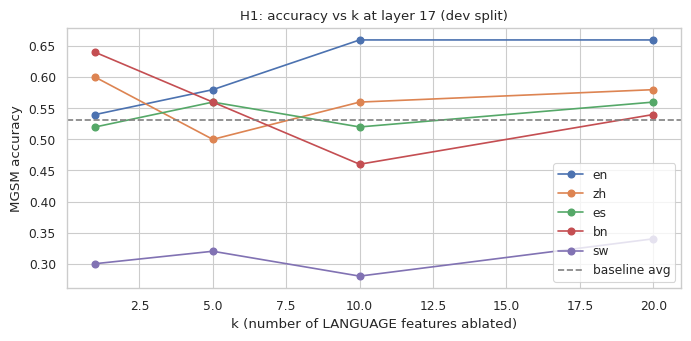

In [16]:
FIG_DIR = Path('results/figures'); FIG_DIR.mkdir(exist_ok=True, parents=True)
sns.set_theme(style='whitegrid', context='paper')

# Figure 1: H1 sweep — accuracy vs k per language.
fig, ax = plt.subplots(figsize=(7, 3.5))
for lang in TARGET_LANGUAGES:
    ys = [h1_sweep[k][lang]['accuracy'] for k in K_VALUES]
    ax.plot(K_VALUES, ys, marker='o', label=lang)
ax.axhline(y=phase2a['baseline_avg'], ls='--', color='grey', label='baseline avg')
ax.set_xlabel('k (number of LANGUAGE features ablated)')
ax.set_ylabel('MGSM accuracy')
ax.set_title(f'H1: accuracy vs k at layer {PRIMARY_LAYER} (dev split)')
ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig(FIG_DIR / 'fig7_h1_sweep.png', dpi=150); plt.show()

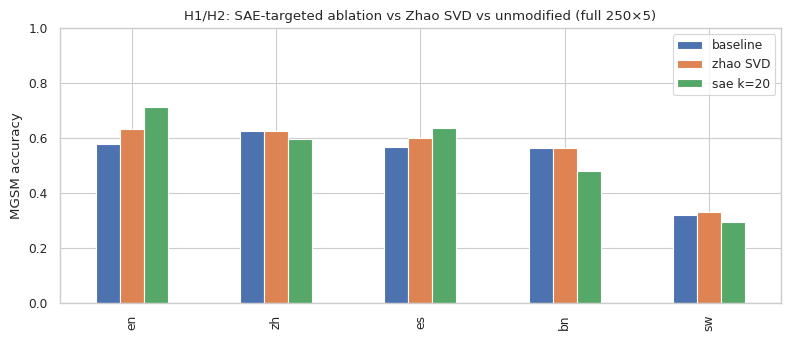

In [17]:
# Figure 2: H1/H2 final comparison (baseline / zhao / sae) per language.
fig, ax = plt.subplots(figsize=(8, 3.5))
df = pd.DataFrame({
    'baseline': {l: baseline_results[l]['accuracy'] for l in TARGET_LANGUAGES},
    'zhao SVD': {l: zhao_test[l]['accuracy'] for l in TARGET_LANGUAGES},
    f'sae k={best_k}': {l: h1_test[l]['accuracy'] for l in TARGET_LANGUAGES},
})
df.plot(kind='bar', ax=ax)
ax.set_ylabel('MGSM accuracy'); ax.set_ylim(0, 1)
ax.set_title('H1/H2: SAE-targeted ablation vs Zhao SVD vs unmodified (full 250×5)')
plt.tight_layout(); plt.savefig(FIG_DIR / 'fig8_h1h2_final.png', dpi=150); plt.show()

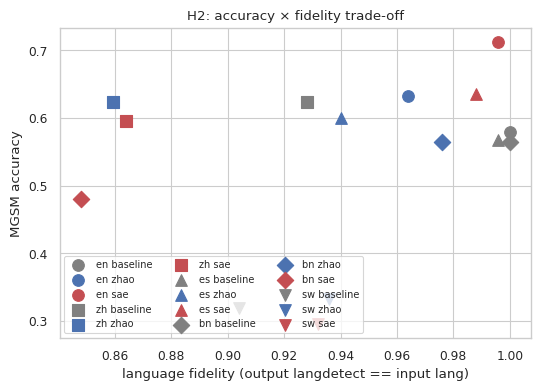

In [18]:
# Figure 3: H2 — accuracy vs language fidelity scatter
fig, ax = plt.subplots(figsize=(5.5, 4))
for lang, marker in zip(TARGET_LANGUAGES, ['o', 's', '^', 'D', 'v']):
    ax.scatter(fidelity[lang]['baseline'], baseline_results[lang]['accuracy'],
               marker=marker, s=70, color='grey',  label=f'{lang} baseline')
    ax.scatter(fidelity[lang]['zhao'],     zhao_test[lang]['accuracy'],
               marker=marker, s=70, color='C0',    label=f'{lang} zhao')
    ax.scatter(fidelity[lang]['sae'],      h1_test[lang]['accuracy'],
               marker=marker, s=70, color='C3',    label=f'{lang} sae')
ax.set_xlabel('language fidelity (output langdetect == input lang)')
ax.set_ylabel('MGSM accuracy')
ax.set_title('H2: accuracy × fidelity trade-off')
ax.legend(fontsize=7, loc='lower left', ncol=3)
plt.tight_layout(); plt.savefig(FIG_DIR / 'fig9_h2_tradeoff.png', dpi=150); plt.show()

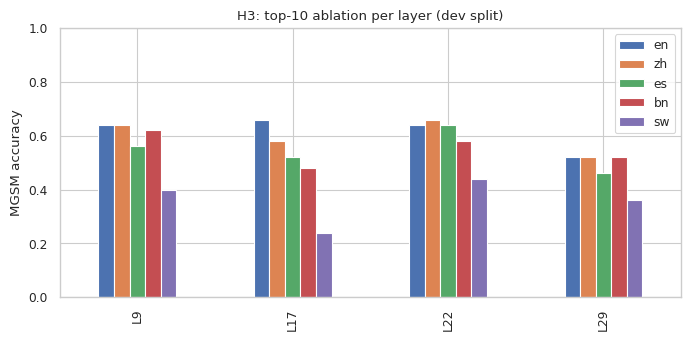

In [19]:
# Figure 4: H3 layer-wise accuracy.
fig, ax = plt.subplots(figsize=(7, 3.5))
df = pd.DataFrame({
    f'L{layer}': {l: h3_results[layer][l]['accuracy'] for l in TARGET_LANGUAGES}
    for layer in SAE_SUBSET_LAYERS
})
df.T.plot(kind='bar', ax=ax)
ax.set_ylabel('MGSM accuracy'); ax.set_ylim(0, 1)
ax.set_title(f'H3: top-{K_H3} ablation per layer (dev split)')
plt.tight_layout(); plt.savefig(FIG_DIR / 'fig10_h3_layers.png', dpi=150); plt.show()

## 10. Bootstrap CIs and save

In [20]:
def bootstrap_ci(correct_list, n_boot=1000, seed=0):
    rng = np.random.default_rng(seed)
    arr = np.asarray(correct_list, dtype=float)
    boots = [arr[rng.integers(0, len(arr), size=len(arr))].mean() for _ in range(n_boot)]
    return (float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5)))

ci_summary = {}
for lang in TARGET_LANGUAGES:
    ci_summary[lang] = {
        'baseline': bootstrap_ci(baseline_results[lang]['correct']),
        'zhao':     bootstrap_ci(zhao_test[lang]['correct']),
        'sae':      bootstrap_ci(h1_test[lang]['correct']),
    }
    base_mean = baseline_results[lang]['accuracy']
    z_mean    = zhao_test[lang]['accuracy']
    s_mean    = h1_test[lang]['accuracy']
    print(f'{lang}: baseline {base_mean:.3f} {ci_summary[lang]["baseline"]} | '
          f'zhao {z_mean:.3f} {ci_summary[lang]["zhao"]} | '
          f'sae {s_mean:.3f} {ci_summary[lang]["sae"]}')

en: baseline 0.580 (0.516, 0.64) | zhao 0.632 (0.576, 0.688) | sae 0.712 (0.652, 0.768)
zh: baseline 0.624 (0.564, 0.688) | zhao 0.624 (0.568, 0.684) | sae 0.596 (0.54, 0.656)
es: baseline 0.568 (0.5119, 0.628) | zhao 0.600 (0.536, 0.664) | sae 0.636 (0.576, 0.696)
bn: baseline 0.564 (0.508, 0.628) | zhao 0.564 (0.504, 0.624) | sae 0.480 (0.416, 0.54)
sw: baseline 0.320 (0.268, 0.38) | zhao 0.332 (0.276, 0.388) | sae 0.296 (0.244, 0.352)


In [21]:
phase2b_payload = {
    'config': {
        'primary_layer': PRIMARY_LAYER, 'k_values': K_VALUES, 'best_k': best_k,
        'k_h3': K_H3, 'n_dev': N_DEV, 'n_test': N_TEST,
        'max_new_tokens': MAX_NEW_TOKENS,
        'random_features_seed_0': random_features,
    },
    'causal_labels': causal_labels,
    'confirmed_language': confirmed_language,
    'baseline_acc_label_dev': label_baseline_acc,
    'baseline_ppl': baseline_ppl,
    'h1_sweep': h1_sweep,
    'ctrl_random': ctrl_random,
    'ctrl_deng': ctrl_deng,
    'h1_test': h1_test,
    'fidelity': fidelity,
    'h3_results': h3_results,
    'ci_summary': ci_summary,
    'best_k': best_k,
    'h1_test_avg': h1_test_avg,
}
out = RESULTS_DIR / 'phase2_ablation.pt'
torch.save(phase2b_payload, out)
print(f'Saved {out} ({out.stat().st_size/1e6:.1f} MB)')
if DRIVE_RESULTS is not None:
    torch.save(phase2b_payload, DRIVE_RESULTS / 'phase2_ablation.pt')

print('\n=== Phase 2b summary ===')
print(f'Causal labels by tag:')
from collections import Counter
tag_counts = Counter(v['tag'] for v in causal_labels.values())
print(f'  {dict(tag_counts)}')
print(f'Best k = {best_k}')
print(f'Avg accuracy:')
print(f'  baseline: {phase2a["baseline_avg"]:.3f}')
print(f'  zhao:     {phase2a["zhao_avg"]:.3f}')
print(f'  sae k={best_k}: {h1_test_avg:.3f}')
print(f'  random k={best_k} (dev): {avg_acc(ctrl_random):.3f}')
print(f'  deng-style k={best_k} (dev): {avg_acc(ctrl_deng):.3f}')

Saved /workspace/nlp-project/results/phase2_ablation.pt (3.1 MB)

=== Phase 2b summary ===
Causal labels by tag:
  {'LANGUAGE': 13, 'SHARED': 10, 'JUNK': 1, 'REASONING': 1}
Best k = 20
Avg accuracy:
  baseline: 0.531
  zhao:     0.550
  sae k=20: 0.544
  random k=20 (dev): 0.528
  deng-style k=20 (dev): 0.560
